# Imbalanced Data: Do Problema às Soluções
## Oversampling, Undersampling e Técnicas Avançadas

---

## Sumário

1. O Problema dos Dados Desbalanceados
2. Métricas para Dados Desbalanceados
3. Undersampling (Random)
4. Oversampling (Random)
5. SMOTE (Synthetic Minority Over-sampling)
6. ADASYN (Adaptive Synthetic Sampling)
7. Tomek Links
8. Combinações de Técnicas
9. Comparação Prática
10. Quando Usar Cada Técnica

---
## 1. O Problema dos Dados Desbalanceados

### O que é Imbalanced Data?

**Definição:** Quando as classes no dataset têm distribuição muito desigual.

**Exemplo:**
- Detecção de fraude: 99% transações normais, 1% fraudes
- Diagnóstico de doenças raras: 95% saudáveis, 5% doentes
- Detecção de spam: 90% emails legítimos, 10% spam

### Por que é um problema?

**1. Bias do Modelo:**
O modelo aprende a simplesmente prever a classe majoritária.

**Exemplo:**
- Dataset: 95% classe A, 5% classe B
- Modelo sempre prevê A → 95% de acurácia
- Mas não aprendeu nada sobre B!

**2. Métricas Enganosas:**
Alta acurácia não significa bom modelo.

**3. Importância Assimétrica:**
Muitas vezes a classe minoritária é a mais importante:
- Detectar fraude (minoritária) é crucial
- Não detectar fraude (falso negativo) é caro

### Visualização do Problema

---

In [1]:
# Setup inicial
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    ConfusionMatrixDisplay
)
import warnings
warnings.filterwarnings('ignore')

# Configurações
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("Bibliotecas importadas com sucesso")

Bibliotecas importadas com sucesso


In [2]:
# Criar dataset desbalanceado
X, y = make_classification(
    n_samples=1000,
    n_features=2,
    n_informative=2,
    n_redundant=0,
    n_clusters_per_class=1,
    weights=[0.95, 0.05],  # 95% classe 0, 5% classe 1
    flip_y=0.01,
    random_state=42
)

# Criar DataFrame
df_imbalanced = pd.DataFrame(X, columns=['Feature_1', 'Feature_2'])
df_imbalanced['Class'] = y

print("DATASET DESBALANCEADO CRIADO")
print("="*70)
print(f"Total de amostras: {len(df_imbalanced)}")
print("\nDistribuição de classes:")
print(df_imbalanced['Class'].value_counts())
print("\nProporção:")
print(df_imbalanced['Class'].value_counts(normalize=True))

# Calcular imbalance ratio
majority_count = df_imbalanced['Class'].value_counts()[0]
minority_count = df_imbalanced['Class'].value_counts()[1]
imbalance_ratio = majority_count / minority_count

print(f"\nImbalance Ratio: {imbalance_ratio:.2f}:1")
print(f"Isso significa: Para cada exemplo da classe minoritária,")
print(f"há {imbalance_ratio:.0f} exemplos da classe majoritária")

DATASET DESBALANCEADO CRIADO
Total de amostras: 1000

Distribuição de classes:
Class
0    945
1     55
Name: count, dtype: int64

Proporção:
Class
0    0.945
1    0.055
Name: proportion, dtype: float64

Imbalance Ratio: 17.18:1
Isso significa: Para cada exemplo da classe minoritária,
há 17 exemplos da classe majoritária


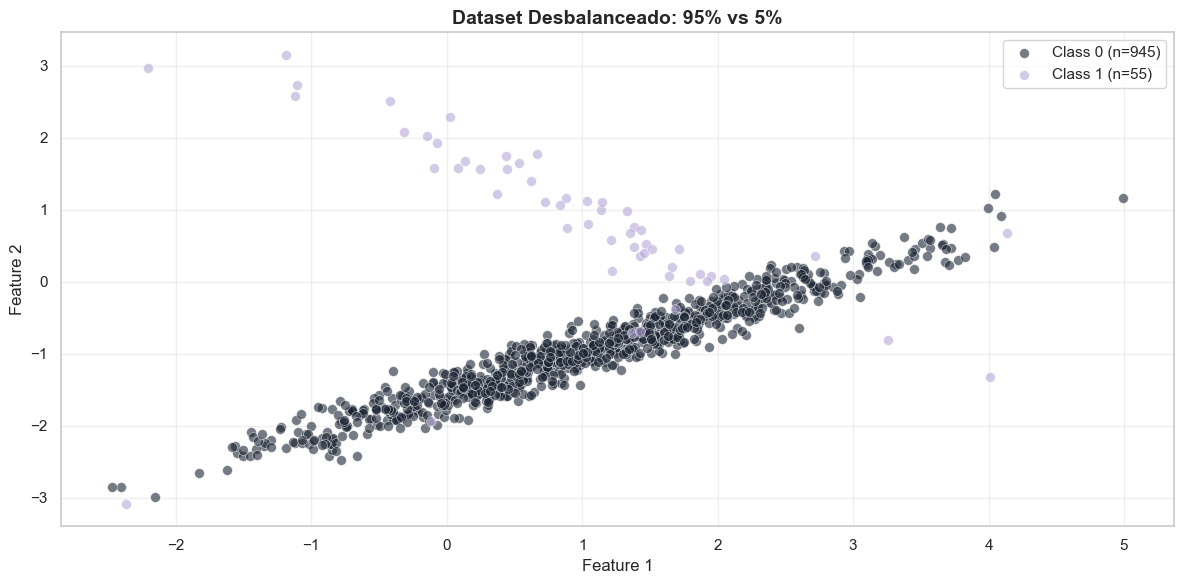


Observação: A classe minoritária (roxa) é quase invisível!


In [3]:
# Visualizar dados desbalanceados
plt.figure(figsize=(12, 6))

colors = ['#1A2332', '#B4A7D6']
for class_value in [0, 1]:
    subset = df_imbalanced[df_imbalanced['Class'] == class_value]
    plt.scatter(subset['Feature_1'], subset['Feature_2'],
                c=colors[class_value], label=f'Class {class_value} (n={len(subset)})',
                alpha=0.6, s=50, edgecolors='white', linewidth=0.5)

plt.xlabel('Feature 1', fontsize=12)
plt.ylabel('Feature 2', fontsize=12)
plt.title('Dataset Desbalanceado: 95% vs 5%', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("\nObservação: A classe minoritária (roxa) é quase invisível!")

### Problema na Prática

In [4]:
# Treinar modelo sem balanceamento
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Modelo simples
model_baseline = LogisticRegression(random_state=42)
model_baseline.fit(X_train, y_train)

# Predições
y_pred_baseline = model_baseline.predict(X_test)

# Métricas
accuracy = accuracy_score(y_test, y_pred_baseline)
precision = precision_score(y_test, y_pred_baseline)
recall = recall_score(y_test, y_pred_baseline)
f1 = f1_score(y_test, y_pred_baseline)

print("MODELO SEM BALANCEAMENTO")
print("="*70)
print(f"Acurácia:  {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")

print("\nMatriz de Confusão:")
cm = confusion_matrix(y_test, y_pred_baseline)
print(cm)

print("\nInterpretação:")
print(f"- True Negatives (TN): {cm[0, 0]} (correto: previu 0, era 0)")
print(f"- False Positives (FP): {cm[0, 1]} (erro: previu 1, era 0)")
print(
    f"- False Negatives (FN): {cm[1, 0]} (erro: previu 0, era 1) ⚠️ PROBLEMA!")
print(f"- True Positives (TP): {cm[1, 1]} (correto: previu 1, era 1)")

MODELO SEM BALANCEAMENTO
Acurácia:  0.9733 (97.33%)
Precision: 1.0000
Recall:    0.5000
F1-Score:  0.6667

Matriz de Confusão:
[[284   0]
 [  8   8]]

Interpretação:
- True Negatives (TN): 284 (correto: previu 0, era 0)
- False Positives (FP): 0 (erro: previu 1, era 0)
- False Negatives (FN): 8 (erro: previu 0, era 1) ⚠️ PROBLEMA!
- True Positives (TP): 8 (correto: previu 1, era 1)


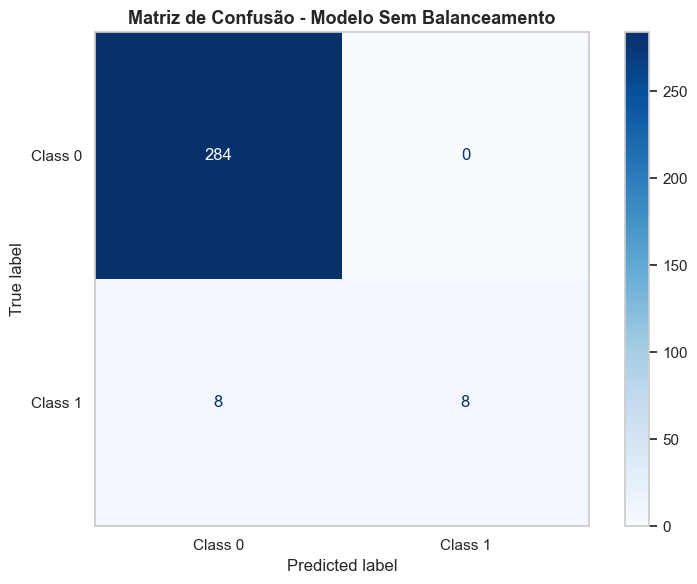


Problema: Modelo tem alta acurácia (97.3%) mas péssimo recall (50.0%)
Isso significa que não detecta a classe minoritária!


In [5]:
# Visualizar matriz de confusão
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm, display_labels=['Class 0', 'Class 1'])
disp.plot(ax=ax, cmap='Blues', colorbar=True)
ax.set_title('Matriz de Confusão - Modelo Sem Balanceamento',
             fontsize=13, fontweight='bold')
ax.grid(False)
plt.tight_layout()
plt.show()

print(
    f"\nProblema: Modelo tem alta acurácia ({accuracy*100:.1f}%) mas péssimo recall ({recall*100:.1f}%)")
print("Isso significa que não detecta a classe minoritária!")

---
## 2. Métricas para Dados Desbalanceados

### Por que Acurácia não é Suficiente?

**Cenário:** 95% classe 0, 5% classe 1

**Modelo Ingênuo:** Sempre prevê classe 0
- Acurácia: 95%
- Mas não aprendeu nada!

### Métricas Importantes

**1. Precision (Precisão)**

$$
\text{Precision} = \frac{TP}{TP + FP}
$$

Do que o modelo previu como positivo, quantos % estavam corretos?

**2. Recall (Revocação / Sensibilidade)**

$$
\text{Recall} = \frac{TP}{TP + FN}
$$

Dos exemplos que realmente eram positivos, quantos % o modelo detectou?

**3. F1-Score**

$$
F1 = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}
$$

Média harmônica entre Precision e Recall.

**4. AUC-ROC**

Área sob a curva ROC. Mede a capacidade de discriminação do modelo.



### Qual usar?

**Precision:** Quando falso positivo é caro
- Exemplo: Spam (não quer marcar email legítimo como spam)

**Recall:** Quando falso negativo é caro
- Exemplo: Fraude (não quer deixar fraude passar)

**F1-Score:** Balanço entre os dois


In [6]:
# Função para calcular e exibir todas as métricas
def evaluate_model(y_true, y_pred, model_name="Model"):
    """
    Calcula e exibe todas as métricas relevantes
    """
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    print(f"\n{model_name}")
    print("="*70)
    print(f"Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
    print(f"Precision: {precision:.4f} ({precision*100:.2f}%)")
    print(f"Recall:    {recall:.4f} ({recall*100:.2f}%)")
    print(f"F1-Score:  {f1:.4f}")

    cm = confusion_matrix(y_true, y_pred)
    print(f"\nConfusion Matrix:")
    print(f"  TN={cm[0, 0]:3d}  FP={cm[0, 1]:3d}")
    print(f"  FN={cm[1, 0]:3d}  TP={cm[1, 1]:3d}")

    return {
        'Model': model_name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1
    }


# Demonstrar com modelo baseline
baseline_metrics = evaluate_model(
    y_test, y_pred_baseline, "Baseline (Sem Balanceamento)")


Baseline (Sem Balanceamento)
Accuracy:  0.9733 (97.33%)
Precision: 1.0000 (100.00%)
Recall:    0.5000 (50.00%)
F1-Score:  0.6667

Confusion Matrix:
  TN=284  FP=  0
  FN=  8  TP=  8


---
## 3. Undersampling (Random)

### Conceito

**Undersampling:** Reduzir o número de exemplos da classe majoritária para igualar à minoritária.

### Como Funciona

1. Contar exemplos da classe minoritária (n_min)
2. Amostrar aleatoriamente n_min exemplos da classe majoritária
3. Combinar ambas as classes

### Fórmula

$$
\text{Dataset Balanceado} = \text{Classe Minoritária} + \text{Random Sample}(\text{Classe Majoritária}, n_{\text{min}})
$$

### Vantagens

- Simples de implementar
- Reduz tempo de treinamento
- Reduz requisitos de memória

### Desvantagens

- Perde informação (descarta dados)
- Pode perder padrões importantes
- Performance pode cair

### Quando Usar

- Dataset muito grande
- Tempo/memória são limitados
- Classe majoritária tem muita redundância

---


In [7]:
# Implementação manual de Random Undersampling
def random_undersampling(X, y, random_state=42):
    """
    Aplica random undersampling
    """
    np.random.seed(random_state)

    # Separar classes
    X_majority = X[y == 0]
    X_minority = X[y == 1]
    y_majority = y[y == 0]
    y_minority = y[y == 1]

    # Número de exemplos da classe minoritária
    n_minority = len(X_minority)

    # Amostrar aleatoriamente da classe majoritária
    indices = np.random.choice(len(X_majority), n_minority, replace=False)
    X_majority_sampled = X_majority[indices]
    y_majority_sampled = y_majority[indices]

    # Combinar
    X_balanced = np.vstack([X_majority_sampled, X_minority])
    y_balanced = np.concatenate([y_majority_sampled, y_minority])

    # Embaralhar
    shuffle_indices = np.random.permutation(len(X_balanced))
    X_balanced = X_balanced[shuffle_indices]
    y_balanced = y_balanced[shuffle_indices]

    return X_balanced, y_balanced


# Aplicar undersampling
X_train_under, y_train_under = random_undersampling(X_train, y_train)

print("RANDOM UNDERSAMPLING")
print("="*70)
print(f"\nAntes:")
print(f"  Total: {len(y_train)}")
print(f"  Class 0: {(y_train == 0).sum()}")
print(f"  Class 1: {(y_train == 1).sum()}")

print(f"\nDepois:")
print(f"  Total: {len(y_train_under)}")
print(f"  Class 0: {(y_train_under == 0).sum()}")
print(f"  Class 1: {(y_train_under == 1).sum()}")

print(
    f"\nDados removidos: {len(y_train) - len(y_train_under)} ({(1 - len(y_train_under)/len(y_train))*100:.1f}%)")

RANDOM UNDERSAMPLING

Antes:
  Total: 700
  Class 0: 661
  Class 1: 39

Depois:
  Total: 78
  Class 0: 39
  Class 1: 39

Dados removidos: 622 (88.9%)


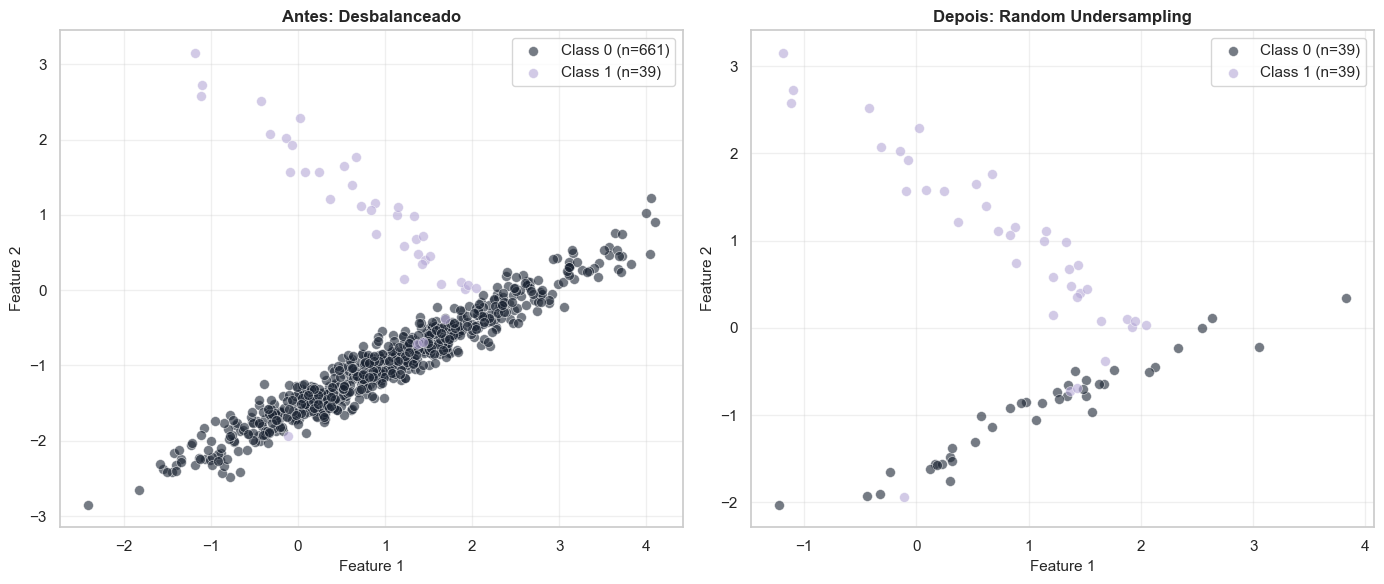

In [8]:
# Visualizar antes e depois
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Antes
for class_value in [0, 1]:
    subset = X_train[y_train == class_value]
    axes[0].scatter(subset[:, 0], subset[:, 1],
                    c=colors[class_value], label=f'Class {class_value} (n={len(subset)})',
                    alpha=0.6, s=50, edgecolors='white', linewidth=0.5)

axes[0].set_xlabel('Feature 1', fontsize=11)
axes[0].set_ylabel('Feature 2', fontsize=11)
axes[0].set_title('Antes: Desbalanceado', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Depois
for class_value in [0, 1]:
    subset = X_train_under[y_train_under == class_value]
    axes[1].scatter(subset[:, 0], subset[:, 1],
                    c=colors[class_value], label=f'Class {class_value} (n={len(subset)})',
                    alpha=0.6, s=50, edgecolors='white', linewidth=0.5)

axes[1].set_xlabel('Feature 1', fontsize=11)
axes[1].set_ylabel('Feature 2', fontsize=11)
axes[1].set_title('Depois: Random Undersampling',
                  fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [9]:
# Treinar modelo com undersampling
model_under = LogisticRegression(random_state=42)
model_under.fit(X_train_under, y_train_under)

# Predições
y_pred_under = model_under.predict(X_test)

# Avaliar
under_metrics = evaluate_model(y_test, y_pred_under, "Random Undersampling")

print("\nComparação:")
print(f"Baseline - Recall: {baseline_metrics['Recall']:.4f}")
print(f"Undersampling - Recall: {under_metrics['Recall']:.4f}")
print(
    f"Melhoria no Recall: {(under_metrics['Recall'] - baseline_metrics['Recall'])*100:.1f}%")


Random Undersampling
Accuracy:  0.9733 (97.33%)
Precision: 0.7500 (75.00%)
Recall:    0.7500 (75.00%)
F1-Score:  0.7500

Confusion Matrix:
  TN=280  FP=  4
  FN=  4  TP= 12

Comparação:
Baseline - Recall: 0.5000
Undersampling - Recall: 0.7500
Melhoria no Recall: 25.0%


---
## 4. Oversampling (Random)

### Conceito

**Oversampling:** Aumentar o número de exemplos da classe minoritária replicando exemplos existentes.

### Como Funciona

1. Contar exemplos da classe majoritária (n_maj)
2. Amostrar aleatoriamente (com reposição) da classe minoritária até ter n_maj exemplos
3. Combinar ambas as classes

### Fórmula

$$
\text{Dataset Balanceado} = \text{Classe Majoritária} + \text{Random Sample With Replacement}(\text{Classe Minoritária}, n_{\text{maj}})
$$

### Vantagens

- Não perde informação
- Simples de implementar
- Mantém todos os exemplos originais

### Desvantagens

- Overfitting (replica exemplos exatos)
- Aumenta tamanho do dataset
- Não adiciona nova informação

### Quando Usar

- Dataset pequeno
- Não pode perder dados
- Como baseline simples

---

In [10]:
# Implementação manual de Random Oversampling
def random_oversampling(X, y, random_state=42):
    """
    Aplica random oversampling
    """
    np.random.seed(random_state)

    # Separar classes
    X_majority = X[y == 0]
    X_minority = X[y == 1]
    y_majority = y[y == 0]
    y_minority = y[y == 1]

    # Número de exemplos da classe majoritária
    n_majority = len(X_majority)

    # Amostrar com reposição da classe minoritária
    indices = np.random.choice(len(X_minority), n_majority, replace=True)
    X_minority_sampled = X_minority[indices]
    y_minority_sampled = y_minority[indices]

    # Combinar
    X_balanced = np.vstack([X_majority, X_minority_sampled])
    y_balanced = np.concatenate([y_majority, y_minority_sampled])

    # Embaralhar
    shuffle_indices = np.random.permutation(len(X_balanced))
    X_balanced = X_balanced[shuffle_indices]
    y_balanced = y_balanced[shuffle_indices]

    return X_balanced, y_balanced


# Aplicar oversampling
X_train_over, y_train_over = random_oversampling(X_train, y_train)

print("RANDOM OVERSAMPLING")
print("="*70)
print(f"\nAntes:")
print(f"  Total: {len(y_train)}")
print(f"  Class 0: {(y_train == 0).sum()}")
print(f"  Class 1: {(y_train == 1).sum()}")

print(f"\nDepois:")
print(f"  Total: {len(y_train_over)}")
print(f"  Class 0: {(y_train_over == 0).sum()}")
print(f"  Class 1: {(y_train_over == 1).sum()}")

print(
    f"\nDados adicionados: {len(y_train_over) - len(y_train)} ({(len(y_train_over)/len(y_train) - 1)*100:.1f}% de aumento)")

RANDOM OVERSAMPLING

Antes:
  Total: 700
  Class 0: 661
  Class 1: 39

Depois:
  Total: 1322
  Class 0: 661
  Class 1: 661

Dados adicionados: 622 (88.9% de aumento)


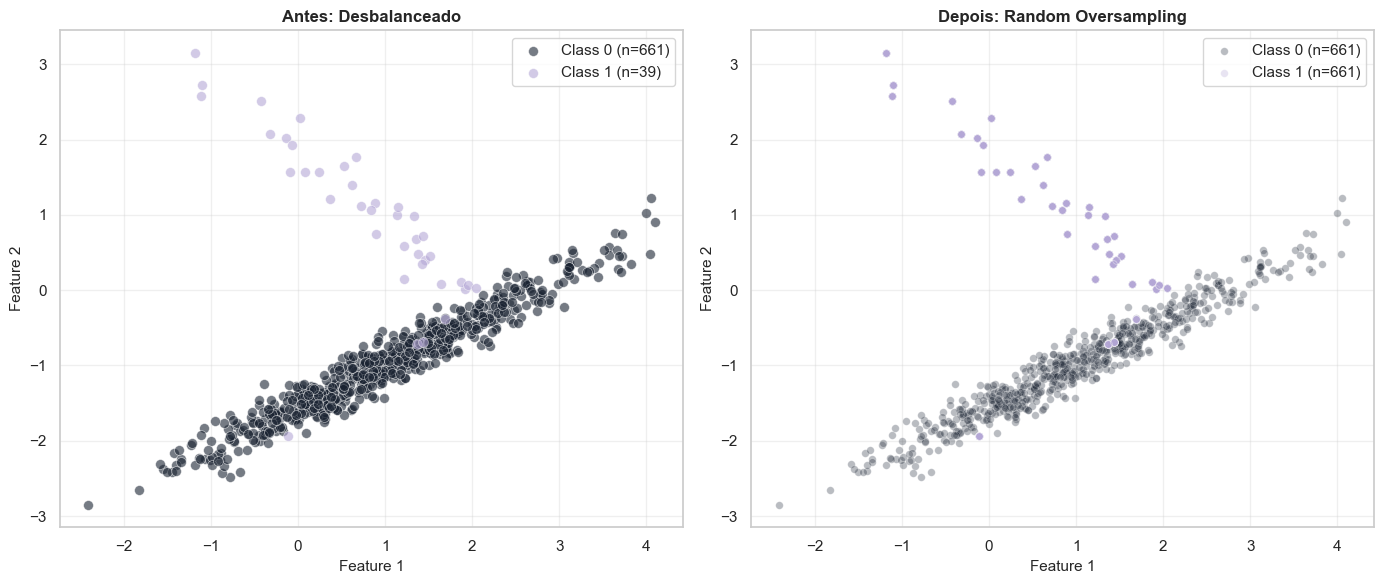


Observação: Pontos sobrepostos (duplicatas) aparecem mais escuros


In [11]:
# Visualizar antes e depois
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Antes
for class_value in [0, 1]:
    subset = X_train[y_train == class_value]
    axes[0].scatter(subset[:, 0], subset[:, 1],
                    c=colors[class_value], label=f'Class {class_value} (n={len(subset)})',
                    alpha=0.6, s=50, edgecolors='white', linewidth=0.5)

axes[0].set_xlabel('Feature 1', fontsize=11)
axes[0].set_ylabel('Feature 2', fontsize=11)
axes[0].set_title('Antes: Desbalanceado', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Depois
for class_value in [0, 1]:
    subset = X_train_over[y_train_over == class_value]
    axes[1].scatter(subset[:, 0], subset[:, 1],
                    c=colors[class_value], label=f'Class {class_value} (n={len(subset)})',
                    alpha=0.3, s=30, edgecolors='white', linewidth=0.5)  # Mais transparência

axes[1].set_xlabel('Feature 1', fontsize=11)
axes[1].set_ylabel('Feature 2', fontsize=11)
axes[1].set_title('Depois: Random Oversampling',
                  fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\nObservação: Pontos sobrepostos (duplicatas) aparecem mais escuros")

In [12]:
# Treinar modelo com oversampling
model_over = LogisticRegression(random_state=42, max_iter=1000)
model_over.fit(X_train_over, y_train_over)

# Predições
y_pred_over = model_over.predict(X_test)

# Avaliar
over_metrics = evaluate_model(y_test, y_pred_over, "Random Oversampling")

print("\nComparação:")
print(f"Baseline      - Recall: {baseline_metrics['Recall']:.4f}")
print(f"Undersampling - Recall: {under_metrics['Recall']:.4f}")
print(f"Oversampling  - Recall: {over_metrics['Recall']:.4f}")


Random Oversampling
Accuracy:  0.9833 (98.33%)
Precision: 1.0000 (100.00%)
Recall:    0.6875 (68.75%)
F1-Score:  0.8148

Confusion Matrix:
  TN=284  FP=  0
  FN=  5  TP= 11

Comparação:
Baseline      - Recall: 0.5000
Undersampling - Recall: 0.7500
Oversampling  - Recall: 0.6875


---
## 5. SMOTE (Synthetic Minority Over-sampling Technique)

### Conceito

**SMOTE:** Cria exemplos sintéticos da classe minoritária interpolando entre exemplos existentes.

### Como Funciona

**Algoritmo:**
1. Para cada exemplo minoritário
2. Encontre seus \(k\) vizinhos mais próximos (geralmente \(k=5\))
3. Escolha aleatoriamente um dos vizinhos
4. Crie um exemplo sintético no segmento de linha entre eles

### Fórmula Matemática

$$
\mathbf{x}_{\text{new}} = \mathbf{x}_i + \lambda \times (\mathbf{x}_{\text{neighbor}} - \mathbf{x}_i)
$$

**Onde:**
$$
\begin{aligned}
\mathbf{x}_i &= \text{exemplo original} \\
\mathbf{x}_{\text{neighbor}} &= \text{vizinho aleatório escolhido} \\
\lambda &= \text{número aleatório entre 0 e 1} \\
\mathbf{x}_{\text{new}} &= \text{novo exemplo sintético}
\end{aligned}
$$


### Interpretação Geométrica

O novo ponto está **entre** o exemplo original e seu vizinho, criando variação realista.

### Vantagens

- Cria novos exemplos (não duplica)
- Reduz overfitting
- Aumenta variabilidade
- Mais realista que Random Oversampling

### Desvantagens

- Pode criar exemplos em regiões de overlap
- Computacionalmente mais caro
- Precisa de vizinhos próximos

### Quando Usar

- Classe minoritária tem poucos exemplos
- Quer evitar overfitting do Random Oversampling
- Features são contínuas (não categóricas)

---

In [13]:
# Instalar imblearn se necessário
# !pip install imbalanced-learn
from imblearn.over_sampling import SMOTE

# Aplicar SMOTE
smote = SMOTE(random_state=42, k_neighbors=5)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("SMOTE (Synthetic Minority Over-sampling Technique)")
print("="*70)
print(f"\nAntes:")
print(f"  Total: {len(y_train)}")
print(f"  Class 0: {(y_train == 0).sum()}")
print(f"  Class 1: {(y_train == 1).sum()}")

print(f"\nDepois:")
print(f"  Total: {len(y_train_smote)}")
print(f"  Class 0: {(y_train_smote == 0).sum()}")
print(f"  Class 1: {(y_train_smote == 1).sum()}")

print(
    f"\nExemplos sintéticos criados: {(y_train_smote == 1).sum() - (y_train == 1).sum()}")

SMOTE (Synthetic Minority Over-sampling Technique)

Antes:
  Total: 700
  Class 0: 661
  Class 1: 39

Depois:
  Total: 1322
  Class 0: 661
  Class 1: 661

Exemplos sintéticos criados: 622


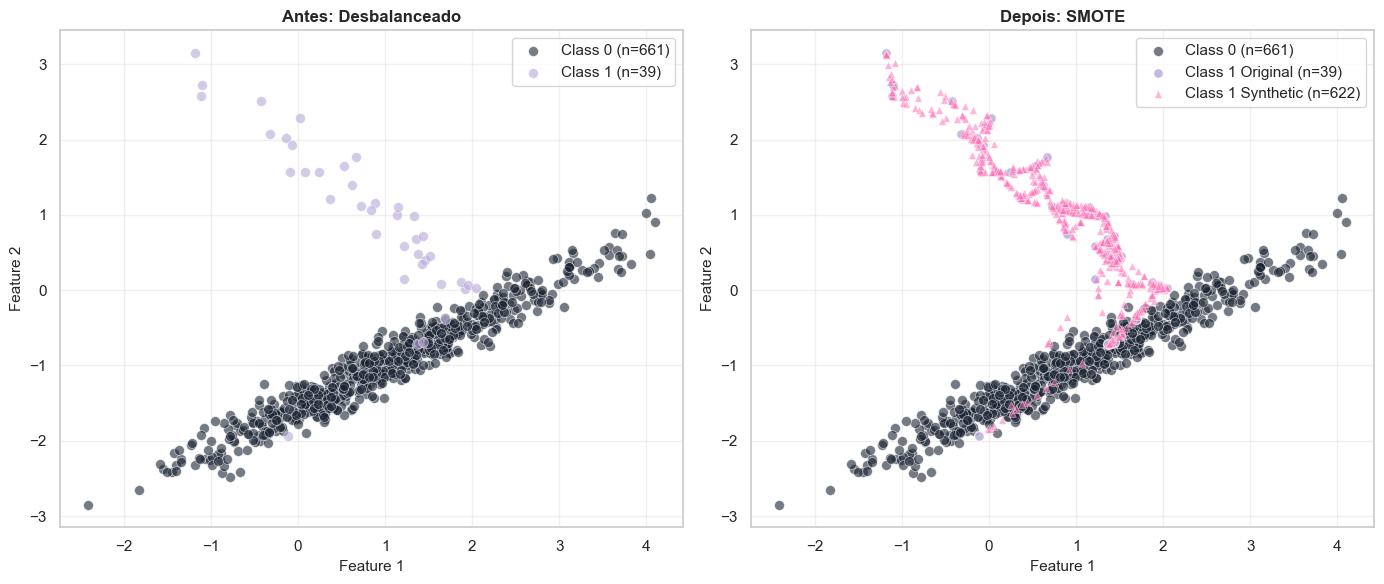

In [16]:
# Visualizar SMOTE
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Antes
for class_value in [0, 1]:
    subset = X_train[y_train == class_value]
    axes[0].scatter(subset[:, 0], subset[:, 1],
                    c=colors[class_value], label=f'Class {class_value} (n={len(subset)})',
                    alpha=0.6, s=50, edgecolors='white', linewidth=0.5)

axes[0].set_xlabel('Feature 1', fontsize=11)
axes[0].set_ylabel('Feature 2', fontsize=11)
axes[0].set_title('Antes: Desbalanceado', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Depois - separar originais e sintéticos
n_original_minority = (y_train == 1).sum()
minority_mask = y_train_smote == 1

# Originais (primeiros n_original_minority)
X_minority_original = X_train_smote[minority_mask][:n_original_minority]
# Sintéticos (restantes)
X_minority_synthetic = X_train_smote[minority_mask][n_original_minority:]

# Plot majoritária
axes[1].scatter(X_train_smote[y_train_smote == 0][:, 0],
                X_train_smote[y_train_smote == 0][:, 1],
                c=colors[0], label=f'Class 0 (n={(y_train_smote == 0).sum()})',
                alpha=0.6, s=50, edgecolors='white', linewidth=0.5)

# Plot minoritária original
axes[1].scatter(X_minority_original[:, 0], X_minority_original[:, 1],
                c=colors[1], label=f'Class 1 Original (n={n_original_minority})',
                alpha=0.8, s=50, edgecolors='white', linewidth=1, marker='o')

# Plot minoritária sintética
axes[1].scatter(X_minority_synthetic[:, 0], X_minority_synthetic[:, 1],
                c='#FF69B4', label=f'Class 1 Synthetic (n={len(X_minority_synthetic)})',
                alpha=0.5, s=30, edgecolors='white', linewidth=0.5, marker='^')

axes[1].set_xlabel('Feature 1', fontsize=11)
axes[1].set_ylabel('Feature 2', fontsize=11)
axes[1].set_title('Depois: SMOTE', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()